In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

In [31]:
df=pd.read_csv('train.csv')

In [32]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
27033,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


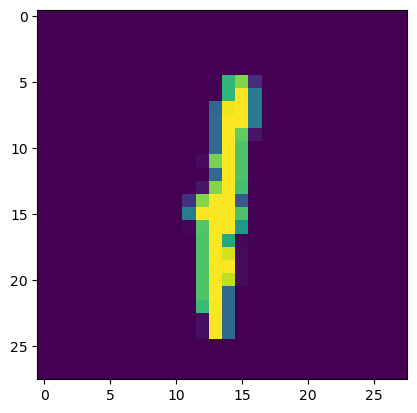

In [34]:
plt.imshow(df.iloc[12,1:].values.reshape(28,28))

In [39]:
X=df.drop(columns='label',axis=1)

In [40]:
X.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [41]:
Y=df['label']

In [54]:
X.shape

(42000, 784)

In [62]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [63]:
Y_train.shape

(33600,)

In [59]:
knn_model=KNeighborsClassifier()

In [64]:
knn_model.fit(X_train,Y_train)

KNeighborsClassifier()

In [65]:
Y_pred=knn_model.predict(X_test)

In [68]:
from sklearn.metrics import accuracy_score
print(accuracy_score(Y_pred,Y_test))

0.9663095238095238


In [81]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [89]:
X_train_trf=scaler.fit_transform(X_train)
X_test_trf=scaler.transform(X_test)

In [90]:
from sklearn.decomposition import PCA
pca=PCA(n_components=200)

In [91]:
X_train_trf=pca.fit_transform(X_train_trf)
X_test_trf=pca.fit_transform(X_test_trf)

In [92]:
X_train_trf.shape

(33600, 200)

In [93]:
knn_model.fit(X_train_trf,Y_train)

KNeighborsClassifier()

In [94]:
Y_pred_trf=knn_model.predict(X_test_trf)

In [96]:
print(accuracy_score(Y_pred_trf,Y_test)*100)

13.797619047619047
